In [1]:
from helper_functions_MTL_IFE import build_dataloaders, build_model, train_model, plot_history, evaluate_model

Epoch 1/30 | Train: 35.26% | Val: 39.97% | LR: 0.000100
Epoch 2/30 | Train: 44.86% | Val: 46.48% | LR: 0.000100
Epoch 3/30 | Train: 47.98% | Val: 49.59% | LR: 0.000100
Epoch 4/30 | Train: 51.10% | Val: 50.00% | LR: 0.000100
Epoch 5/30 | Train: 52.14% | Val: 50.14% | LR: 0.000100
Epoch 6/30 | Train: 54.52% | Val: 51.08% | LR: 0.000100
Epoch 7/30 | Train: 56.77% | Val: 53.79% | LR: 0.000100
Epoch 8/30 | Train: 58.49% | Val: 53.66% | LR: 0.000100
Epoch 9/30 | Train: 59.10% | Val: 58.54% | LR: 0.000100
Epoch 10/30 | Train: 61.04% | Val: 56.50% | LR: 0.000100
Epoch 11/30 | Train: 61.97% | Val: 55.01% | LR: 0.000100
Epoch 12/30 | Train: 62.94% | Val: 55.28% | LR: 0.000050
Epoch 13/30 | Train: 67.52% | Val: 56.64% | LR: 0.000050
Epoch 14/30 | Train: 68.68% | Val: 56.10% | LR: 0.000050
Epoch 15/30 | Train: 70.31% | Val: 52.57% | LR: 0.000025
Epoch 16/30 | Train: 73.04% | Val: 57.72% | LR: 0.000025
Epoch 17/30 | Train: 74.75% | Val: 57.99% | LR: 0.000025
Epoch 18/30 | Train: 75.26% | Val: 56.23

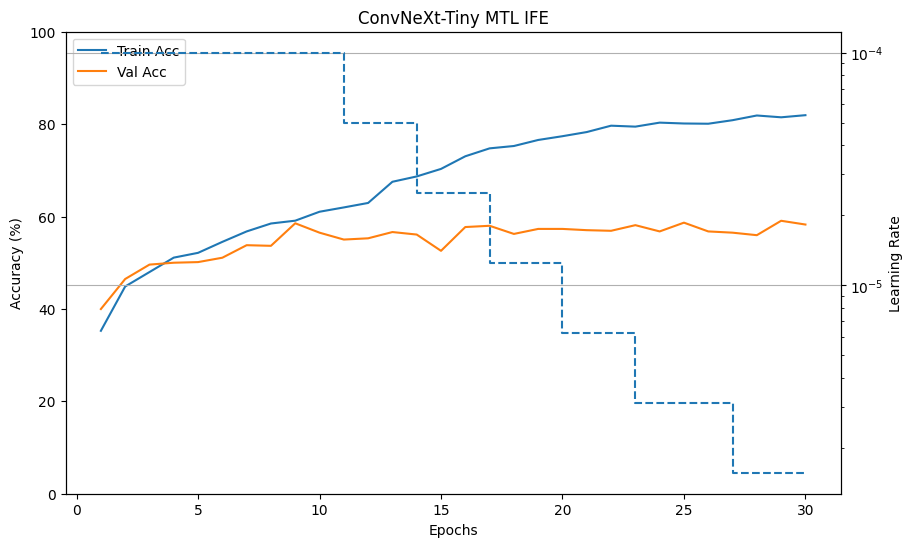


Final Test Accuracy: 66.95%


In [2]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="convnext_tiny",
    pretrained=True,
    use_regularization=True,
    dropout_rate=0.3,
    label_smoothing=0.1,
    weight_decay=1e-3,
    use_scheduler=True,
    scheduler_factor=0.5,
    scheduler_patience=2
)

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=scheduler,
    epochs=30,
    alpha=0.3
)

plot_history(history, "ConvNeXt-Tiny MTL IFE")

test_accuracy = evaluate_model(model, test_loader)